### Loading data and making fits

In [13]:
import os
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage


# Load data from zip file
# zip_path = "data/gym_250126.zip"
zip_path = "data/gym_optimal_250122.zip"
zip_path = "data/gym_optimal_250123.zip"
zip_path = "data/gym_optimal_250128.zip"
zip_path = "data/gym_optimal_250131.zip"
records = []

# max_returns = {
#     "HalfCheetah-v4": 10000,
#     "Hopper-v4": 3500,
#     "Walker2d-v4": 5000,
#     "Ant-v4": 6000,
#     "Humanoid-v4": 5500,
# }
max_returns = {
    "HalfCheetah-v4": 7300 * 1.25,
    "Hopper-v4": 3500 * 1.25,
    "Walker2d-v4": 4000 * 1.25,
    "Ant-v4": 5300 * 1.25,
    "Humanoid-v4": 5200 * 1.25,
}

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for filename in zip_ref.namelist():
        if filename.endswith('.npy'):
            # Extract parameters from directory name (e.g. BRO_64_1_3e-4)
            if filename.startswith('__MACOSX'):
                continue
            _, utd_param, env_name, name, params = os.path.splitext(filename)[0].split('/')
            if name != 'episode.return': 
                continue
            utd = float(utd_param[len('utd_'):])
            params = params.split('_')
            batch_size = int(params[1])
            learning_rate = float(params[3])
            with zip_ref.open(filename) as f:
                arr = np.load(f)
            arr[:, 1:] = 1000 * arr[:, 1:] / max_returns[env_name]
            
            if env_name == 'Hopper-v4': continue
            if utd not in (0.25,0.5,1,2,4,8): continue
                
            # Create record with metadata and results
            records.append({ 
                'env_name': env_name,
                'batch_size': batch_size,
                'utd': utd,
                'learning_rate': learning_rate,
                'training_step': arr[:, 0],
                'return': arr[:, 1:],
                'mean_return': np.mean(arr[:, 1:], axis=1),  # Add summary statistics
                # 'return': arr[:, 1:7],
                # 'mean_return': np.mean(arr[:, 1:7], axis=1),
                'std_return': np.std(arr[:, 1:], axis=1) / np.sqrt(arr.shape[1] - 1)  # Standard Error of Mean over 10 seeds
            })

# Convert to pandas DataFrame
df = pd.DataFrame(records)
# display(df)

# merge additional seeds for hopper-stand and reacher-easy
for env in ['hopper-stand', 'reacher-easy']:
    base_envs = df[df['env_name'] == env]
    seeds_envs = df[df['env_name'] == f'{env}_seeds']
    
    for i in range(len(base_envs)):
        base_env = base_envs.iloc[i]
        seeds_env = seeds_envs.iloc[i]
        
        # Combine returns arrays
        min_length = min(base_env['return'].shape[0], seeds_env['return'].shape[0])
        merged_returns = np.concatenate([base_env['return'][:min_length], seeds_env['return'][:min_length]], axis=1)
        merged_mean = np.mean(merged_returns, axis=1)
        merged_std = np.std(merged_returns, axis=1)
        training_steps = base_env['training_step'][:min_length]

        # Create new row with merged data
        merged_row = base_env.copy()
        merged_row.update({'env_name': f'{env}_merged', 'training_step': training_steps, 'return': merged_returns, 'mean_return': merged_mean, 'std_return': merged_std})
        df = df.append(merged_row, ignore_index=True)

# drop hopper-stand_seeds and reacher-easy_seeds as well as hopper-stand and reacher-easy
df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds', 'hopper-stand', 'reacher-easy'])]

# Add isotonic regression on return data
from sklearn.isotonic import IsotonicRegression
iso_reg_results = []

for _, row in df.iterrows():
    # Initialize isotonic regression model
    ir = IsotonicRegression(out_of_bounds='clip')
    
    # Fit on training steps and mean returns
    x = row['training_step']
    y = row['mean_return']
    # Bootstrap sampling from returns
    # Sample with replacement from the returns at each timestep
    # bootstrap_samples = np.random.choice(row['return'].shape[1], size=row['return'].shape[1], replace=True)
    # y = np.mean(row['return'][:, bootstrap_samples], axis=1)
    # print(row['mean_return'].shape, row['return'].shape)
    
    # Fit the model and get predictions
    ir.fit(x, y)
    y_iso = ir.predict(x)
    
    iso_reg_results.append(y_iso)

# Add isotonic regression results to dataframe    
df['return_isotonic'] = iso_reg_results

# Calculate crossings for each threshold and store in array
# thresholds = [800, 850, 900]
# thresholds = [300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800]
thresholds = [300, 370, 440, 510, 580, 650, 700, 733, 766, 800]
# thresholds = [300, 350, 400, 450, 500, 525, 550, 575, 600, 616, 633, 650, 666, 683, 700, 716, 733, 750, 766, 783, 800]
crossings_array = []

for _, row in df.iterrows():
    row_crossings = []
    for threshold in thresholds:
        # Get crossing from isotonic regression
        crossing_idx = np.where(row['return_isotonic'] > threshold)[0]
        row_crossings.append(row['training_step'][crossing_idx[0]] if len(crossing_idx) > 0 else np.nan)
    
    crossings_array.append(row_crossings)

df['crossings'] = crossings_array

# Remove hopper-stand_seeds and reacher-easy_seeds
# df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds'])]

# df

In [14]:
# Leave only the best runs 

# Get unique environments and UTD ratios
envs = df['env_name'].unique()
utds = df['utd'].unique()

# Create a filtered dataframe
filtered_rows = []

for env in envs:
    env_data = df[df['env_name'] == env]
    
    # For each UTD value
    for utd in utds:
        utd_data = env_data[env_data['utd'] == utd]
        
        if len(utd_data) > 0:
            # Get middle learning rate
            lrs = sorted(utd_data['learning_rate'].unique())
            mid_lr = lrs[len(lrs)//2]
            
            # Get middle batch size
            batch_sizes = sorted(utd_data['batch_size'].unique())
            mid_bs = batch_sizes[len(batch_sizes)//2]
            
            # Get the row with middle lr and bs
            row = utd_data[
                (utd_data['learning_rate'] == mid_lr) & 
                (utd_data['batch_size'] == mid_bs)
            ]
            
            if len(row) > 0:
                filtered_rows.append(row.iloc[0])

# Create new dataframe with filtered rows
df = pd.DataFrame(filtered_rows)


In [15]:
# add error bars via bootstrap

import os
import pickle

# Try to load cached results
cache_file = f'cache/bootstrap_results_{zip_path.split("/")[-1]}.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        results = pickle.load(f)
        iso_reg = results['iso_reg']
        iso_reg_stds = results['iso_reg_stds'] 
        crossings = results['crossings']
        crossings_std = results['crossings_std']
else:
    iso_reg = []
    iso_reg_stds = []
    crossings = []
    crossings_std = []
    for _, row in df.iterrows():    
        n_bootstrap = 100  # Number of bootstrap samples. 100 seems enough for std to converge
        ir = IsotonicRegression(out_of_bounds='clip')
        x = row['training_step']
        y_iso_samples = []
        sample_crossings = []
        for _ in range(n_bootstrap):
            # Sample with replacement
            sample_indices = np.random.randint(0, row['return'].shape[1], size=row['return'].shape[1])
            y = np.mean(row['return'][:, sample_indices], axis=1)  # Average the bootstrap samples
            
            # Fit isotonic regression on this bootstrap sample
            ir.fit(x, y)
            y_iso = ir.predict(x)
            y_iso_samples.append(y_iso)

            # For each bootstrap sample, find threshold crossings
            sample_crossing = []
            for threshold in thresholds:
                crossing_idx = np.where(y_iso > threshold)[0]
                crossing = row['training_step'][crossing_idx[0]] if len(crossing_idx) > 0 else np.nan
                sample_crossing.append(crossing)
            sample_crossings.append(sample_crossing)
        
        # Store mean prediction, crossing statistics, and isotonic std
        iso_reg.append(y_iso_samples)
        crossings.append(np.array(sample_crossings))
        crossings_std.append(np.nanstd(sample_crossings, axis=0))
        iso_reg_stds.append(np.std(y_iso_samples, axis=0))

    # Save results to cache
    results = {
        'iso_reg': iso_reg,
        'iso_reg_stds': iso_reg_stds,
        'crossings': crossings, 
        'crossings_std': crossings_std
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)

df['return_isotonic_bootstrap'] = iso_reg
df['crossings_bootstrap'] = crossings
df['crossings_std'] = crossings_std
df['return_isotonic_std'] = iso_reg_stds

mean_std = np.nanmean(np.array(crossings_std))
print(f"Average standard deviation across all conditions: {mean_std:.2f}")


Average standard deviation across all conditions: 28111.44


In [16]:
# For a particular threshold, get utds and times

envs = sorted([env for env in df['env_name'].unique()])
n_cols = 4
n_rows = (len(envs) + n_cols - 1) // n_cols

env_data_dict = {}

for i, env in enumerate(envs):
    env_df = df[df['env_name'] == env]
    
    # Get UTD and crossing times for this environment, sorted by UTD
    utds = sorted(env_df['utd'].values)
    # Save all thresholds instead of just the last one
    times = [env_df[env_df['utd'] == utd]['crossings'].iloc[0][:] for utd in utds]
    env_data_dict[env] = list(zip(utds, times))
    

# Calculate median times and scaling factors for each environment
median_times = np.array([np.median(list(zip(*env_data_dict[env]))[1]) for env in envs if len(env_data_dict[env]) > 0])
median_median = np.median(median_times)
scaling = 1 / median_times
print(median_times, median_median, median_times.shape)

# Store the normalized data for each environment
normalized_times_all = []
for i, env in enumerate(envs):
    if len(env_data_dict[env]) > 0:
        utds, times = zip(*env_data_dict[env])
        normalized_times = np.array(times) * scaling[i]
        normalized_times_all.append(normalized_times)
        # plt.plot(utds, normalized_times, '--', label=env, alpha=0.5)

# Calculate and plot the average across all environments    
normalized_times_all = np.array(normalized_times_all)
mean_normalized_times = np.mean(normalized_times_all, axis=0)
print(mean_normalized_times[-2, -1] > mean_normalized_times[-1, -1], f'{mean_normalized_times[-2, -1]:.3f}', f'{mean_normalized_times[-1, -1]:.3f}')
n_thresholds = mean_normalized_times.shape[-1]

# Fit a line to log-transformed data
log_utds = np.log(utds)
print(np.array(utds).shape, np.array(normalized_times_all).shape)
log_mean_times = np.log(np.mean(normalized_times_all, axis=0))
slope, intercept = np.polyfit(log_utds, log_mean_times[:, -1], 1)


[360001. 105000. 247501. 233501.] 240501.0 (4,)
True 1.775 1.365
(6,) (4, 6, 10)


In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from ast import arg
import matplotlib.pyplot as plt
from tqdm import tqdm

import scipy

def fit(xs, y, optim_f, init_grid, top_k=500, n_proc=8, tol=None, disp=False, maxiter=None):
        _, _, brute_xs, brute_ys = scipy.optimize.brute(optim_f, init_grid, args=(xs, y), full_output=True, finish=None, Ns=1, workers=-1)

        brute_xs = brute_xs.reshape(brute_xs.shape[0], -1)
        brute_ys = brute_ys.reshape(-1)

        top_idxs = np.argsort(brute_ys)[:top_k]
        top_xs = brute_xs[:, top_idxs]
        # top_ys = brute_ys[top_idxs]
        preds = []
        for i in tqdm(range(top_xs.shape[1])):
            options = {'disp': disp}
            if maxiter: options['maxiter'] = maxiter
            pred = scipy.optimize.minimize(optim_f, top_xs[:, i], args=(xs, y), method='L-BFGS-B', tol=tol, options=options).x
            loss = optim_f(pred, xs, y)
            # print(pred, loss)
            preds.append((pred, loss))
        return sorted(preds, key=lambda x: x[1])[0][0]

def power_law_with_const_min(args, *params):
    x,y = params
    a,b,c = args
    # return ((power_law_with_const(x,a,b,c) - y) ** 2).mean()
    with np.errstate(invalid='ignore', divide='ignore'):
        return ((np.log(power_law_with_const(x,a,b,c) / y)) ** 2).mean()

def power_law_with_const(x, a, b, c): return c * (1 + (x/b)**(-a))


In [18]:
from rliable import plot_utils
COLORS = ['#BBCC33', '#77AADD', '#44BB99',
           '#EEDD88', '#EE8866', '#FFAABB',
          '#99DDFF', '#44BB99', '#AAAA00',
          '#DDDDDD']
palette = sns.set_palette(COLORS)
plt.rcParams['text.usetex'] = False #Let TeX do the typsetting
plt.rcParams['text.latex.preamble'] = r'\usepackage{sansmath} \sansmath' #Force sans-serif math mode (for axes labels)
plt.rcParams['font.family'] = 'sans-serif' # ... for regular text
plt.rcParams['font.sans-serif'] = ['Helveta Nue'] # Choose a nice font here
sns.set_style("whitegrid")


In [19]:
# Pareto fit

# Plot mean data points
fits = []
for i in range(n_thresholds):
    # Fit power law with constant for each threshold
    params = fit(utds[:], mean_normalized_times[:, i], power_law_with_const_min,[slice(-2, 2, 0.8), slice(0, 1, 0.2), slice(-2, 2, 0.8)], maxiter=100)
    # params = fit(utds, mean_normalized_times[:, i], power_law_with_const_min,[slice(-2, 2, 4), slice(0, 1, 1), slice(-2, 2, 4)], maxiter=100)

    a, b, c = params
    fits.append(params)


 27%|██▋       | 34/125 [00:00<00:00, 150.86it/s]/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: overflow encountered in multiply
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
100%|██████████| 125/125 [00:00<00:00, 125.44it/s]


y = 0.74 * (1 + (x/6.27)**(-0.61)


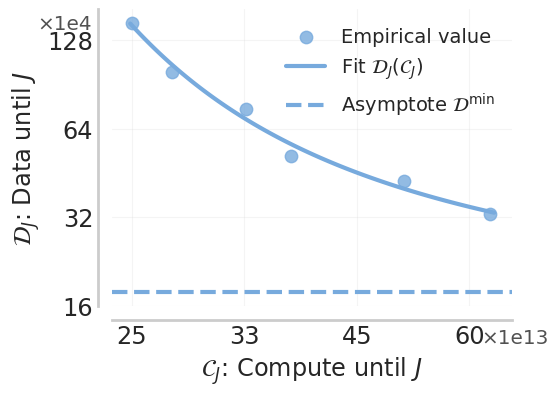

In [20]:
# Pareto fit 

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

from matplotlib.legend_handler import HandlerLine2D, HandlerPathCollection
from matplotlib import collections
import matplotlib.lines as mlines

class HandlerNoMarker(HandlerPathCollection):
    def create_collection(self, *args, **kwargs):
        return mlines.Line2D([], [])
    
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        return mlines.Line2D([], [])

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

print(f'y = {c:.2f} * (1 + (x/{b:.2f})**(-{a:.2f})')

utds = np.array(utds)
data = np.mean(normalized_times_all[..., -1], axis=0) * median_median
utd_line = np.logspace(np.log10(0.25), np.log10(8), 100)
a, b, c = fits[-1]
data_line = power_law_with_const(utd_line, a, b, c) * median_median

grad_steps = utds * data
batch_sizes = 300 * (utds)**(-0.3)
compute = grad_steps * batch_sizes * 10 * 1.5e5

grad_steps_line = utd_line * data_line
batch_sizes_line = 300 * (utd_line)**(-0.3)
compute_line = grad_steps_line * batch_sizes_line * 10 * 1.5e5


plt.scatter(compute[:], data[:], marker='o', color=COLORS[1], label='Empirical value', alpha=0.8, s=80)
# plt.scatter(compute[-1], data[-1], marker='x', color=COLORS[1], label='Extrapolation', alpha=0.8, s=80, linewidth=3)
# plt.scatter(utds, np.mean(normalized_times_all[..., -1], axis=0), marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
plt.plot(compute_line, data_line, COLORS[1], linewidth=3, label='Fit $\mathcal{D}_J(\mathcal{C}_J)$')

# Plot the asymptote
plt.axhline(y=c * median_median, color=COLORS[1], linewidth=3, linestyle='--', label='Asymptote $\mathcal{D}^{\mathrm{min}}$')

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(25e13), np.log10(60e13), num=4)
x_ticks_labels = [f"{x / 1e13:.0f}" for x in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(160000), np.log10(1280000), num=4, dtype=int)
ylabels = ["%2.f" % (y/10000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: Compute until $J$',
                                       ylabel='$\mathcal{D}_J$: Data until $J$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)


plt.text(1.09, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.05, 0.92, '×1e4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)

plt.savefig('gym_frontier_compute_data.pdf', dpi=300, bbox_inches='tight')


### Step 1 - interpolate the pareto frontier from large to small

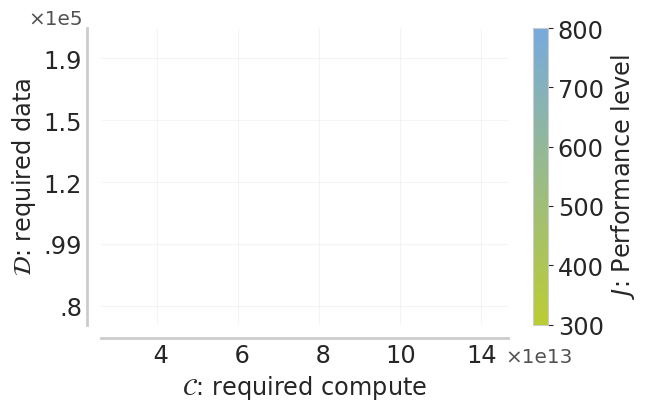

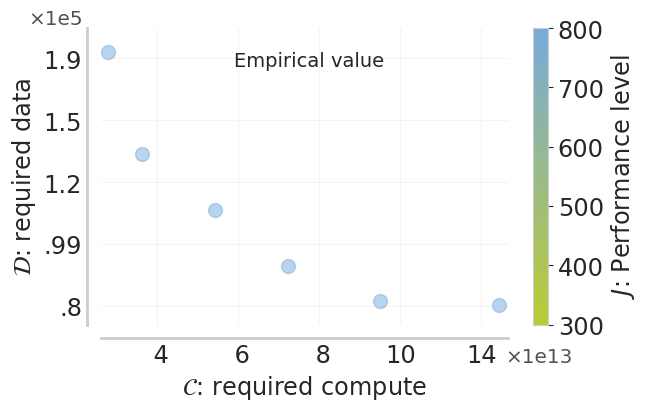

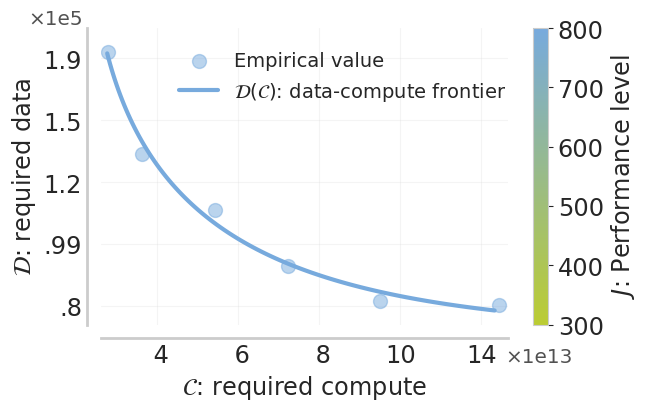

In [21]:

def plot_1_before():
    fig, axs = plt.subplots(1, 1)
    fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

    i = 0
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 300 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 1.5e5

    utd_empirical = utds
    data_empirical = np.mean(normalized_times_all[..., 0], axis=0) * median_median
    # Plot empirical values
    grad_steps_empirical = utd_empirical * data_empirical
    batch_sizes_empirical = 300 * (utd_empirical)**(-0.3)
    compute_empirical = grad_steps_empirical * batch_sizes_empirical * 10 * 1.5e5

    return compute_empirical, data_empirical, compute, data, fig, axs

def plot_1_after(fig, axs):
    plt.xscale('log')
    plt.yscale('log')

    plt.xlim(3.2e13, 16e13)
    x = np.logspace(np.log10(4e13), np.log10(16e13 * 0.9), num=5, dtype=int)
    xlabels = ["%2.f" % (y/1e13) for y in x]
    axs.xaxis.set_major_locator(plt.FixedLocator(x))
    axs.xaxis.set_minor_locator(plt.NullLocator()) 
    axs.set_xticks(x, xlabels, size=14.5)
    
    plt.ylim(75000, 210000)
    yticks = np.logspace(np.log10(80000), np.log10(210000 * 0.9), num=5, dtype=int)
    ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
    axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
    axs.yaxis.set_minor_locator(plt.NullLocator()) 
    axs.set_yticks(yticks, ylabels, size=14.5)

    plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}$: required compute',
                                        ylabel='$\mathcal{D}$: required data',
                                        labelsize='xx-large', ticklabelsize='xx-large',
                                        grid_alpha=0.2, legend=False)

    plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
             horizontalalignment='right', verticalalignment='bottom',
             fontsize='x-large', alpha=0.8)
    plt.text(-0.045, 1, '×1e5', transform=axs.transAxes,
             horizontalalignment='right', verticalalignment='bottom', 
             fontsize='x-large', alpha=0.8)


    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('$J$: Performance level', size='xx-large')
    cbar.ax.tick_params(labelsize='xx-large')


compute_empirical, data_empirical, compute, data, fig, axs = plot_1_before()
# plt.scatter(compute_empirical, data_empirical, color=colors[i], marker='o', s=100, alpha=0.5)
# # plt.plot(compute, data, '-', color=colors[i], linewidth=3)
plot_1_after(fig, axs)
plt.savefig('gif_frontier_empty.png', dpi=300, bbox_inches='tight')

compute_empirical, data_empirical, compute, data, fig, axs = plot_1_before()
plt.scatter(compute_empirical, data_empirical, color=colors[i], marker='o', s=100, alpha=0.5, label='Empirical value')
# plt.plot(compute, data, '-', color=colors[i], linewidth=3)
axs.legend(prop={'size': 14}, ncol=1, frameon=False, bbox_to_anchor=(0.15, 0.98), handler_map={collections.PathCollection: HandlerNoMarker()}, loc='upper left')
plot_1_after(fig, axs)
plt.savefig('gif_frontier_empirical.png', dpi=300, bbox_inches='tight')

compute_empirical, data_empirical, compute, data, fig, axs = plot_1_before()
plt.scatter(compute_empirical, data_empirical, color=colors[i], marker='o', s=100, alpha=0.5, label='Empirical value')
plt.plot(compute, data, '-', color=colors[i], linewidth=3, label='$\mathcal{D}(\mathcal{C})$: data-compute frontier')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, bbox_to_anchor=(0.15, 0.98), loc='upper left')
plot_1_after(fig, axs)
plt.savefig('gif_frontier_fit.png', dpi=300, bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


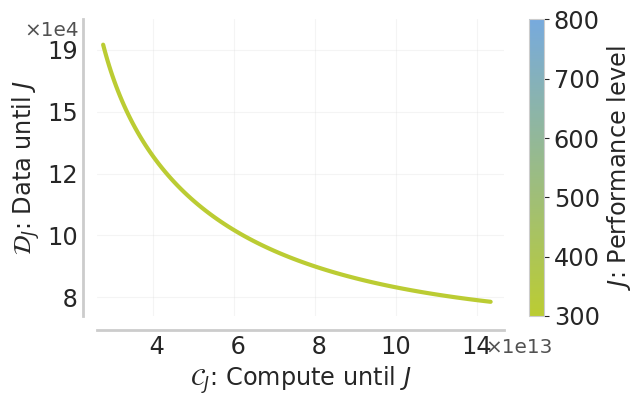

In [22]:
# Step 1 - interpolate the pareto frontier from large to small


fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)


i = 0
# Generate smooth curves and plot fits for each threshold
x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
a, b, c = fits[i]
y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
utd = x_smooth
data = y_fitted

# Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
grad_steps = utd * data
batch_sizes = 300 * (utd)**(-0.3)
compute = grad_steps * batch_sizes * 10 * 1.5e5

# Plot the fit
plt.plot(compute, data, '-',
            color=colors[i],
        #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
            linewidth=3)

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

plt.xlim(3.2e13, 16e13)
x = np.logspace(np.log10(4e13), np.log10(16e13 * 0.9), num=5, dtype=int)
xlabels = ["%2.f" % (y/1e13) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

plt.ylim(75000, 210000)
yticks = np.logspace(np.log10(80000), np.log10(210000 * 0.9), num=5, dtype=int)
ylabels = ["%2.f" % (y/10000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: Compute until $J$',
                                       ylabel='$\mathcal{D}_J$: Data until $J$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.12, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.045, 0.93, '×1e4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$J$: Performance level', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')

plt.savefig('gif_frontier_large.pdf', dpi=300, bbox_inches='tight')


In [23]:
# # Step 1 - interpolate the pareto frontier from large to small

# import matplotlib
# # Create animation frames with increasing limits
# frames = []
# n = 500

# spacing = np.exp(np.linspace(0, 1, n)**2) # Square the parameter to make it more pronounced at the end
# spacing = (spacing - spacing.min()) / (spacing.max() - spacing.min())

# xlims = np.exp(np.log(16e13) + spacing * (np.log(83e13) - np.log(16e13)))
# ylims = np.exp(np.log(210000) + spacing * (np.log(2000000) - np.log(210000)))

# # xlims = np.logspace(np.log10(16e13), np.log10(83e13), n)
# # ylims = np.logspace(np.log10(210000), np.log10(2000000), n)

# for xlim_upper, ylim_upper in tqdm(zip(xlims, ylims)):
#     fig, axs = plt.subplots(1, 1)
#     fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

#     i = 0
#     # Generate smooth curves and plot fits for each threshold
#     x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
#     a, b, c = fits[i]
#     y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
#     utd = x_smooth
#     data = y_fitted

#     # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
#     grad_steps = utd * data
#     batch_sizes = 300 * (utd)**(-0.3)
#     compute = grad_steps * batch_sizes * 10 * 1.5e5

#     # Plot the fit
#     plt.plot(compute, data, '-',
#                 color=colors[i],
#             #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
#                 linewidth=3)

#     plt.xscale('log')
#     plt.yscale('log')
#     axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

#     plt.xlim(3.2e13, xlim_upper)
#     x = np.logspace(np.log10(4e13), np.log10(xlim_upper*0.9), num=5, dtype=int)
#     xlabels = ["%2.f" % (y/1e13) for y in x]
#     axs.xaxis.set_major_locator(plt.FixedLocator(x))
#     axs.xaxis.set_minor_locator(plt.NullLocator()) 
#     axs.set_xticks(x, xlabels, size=14.5)

#     plt.ylim(75000, ylim_upper)
#     yticks = np.logspace(np.log10(80000), np.log10(ylim_upper*0.9), num=5, dtype=int)
#     ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
#     # print(list(yticks))
#     # print(list(y/100000 for y in yticks))
#     # print(list("%.2g" % (y/100000) for y in yticks))
#     axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
#     axs.yaxis.set_minor_locator(plt.NullLocator()) 
#     axs.set_yticks(yticks, ylabels, size=14.5)

#     plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}$: required compute',
#                                            ylabel='$\mathcal{D}$: required data',
#                                            labelsize='xx-large', ticklabelsize='xx-large',
#                                            grid_alpha=0.2, legend=False)

#     plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
#              horizontalalignment='right', verticalalignment='bottom',
#              fontsize='x-large', alpha=0.8)
#     plt.text(-0.045, 1, '×1e5', transform=axs.transAxes,
#              horizontalalignment='right', verticalalignment='bottom', 
#              fontsize='x-large', alpha=0.8)

#     # Add colorbar
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
#     sm.set_array([])
#     cbar = plt.colorbar(sm, ax=plt.gca())
#     cbar.set_label('$J$: Performance level', size='xx-large')
#     cbar.ax.tick_params(labelsize='xx-large')

#     fig.canvas.draw()
#     fig.canvas.flush_events()
#     # Save frame
#     plt.savefig(f'./gifs/gif_zoom_frame_{len(frames):03d}.png', dpi=300, bbox_inches='tight', format='png')
#     frames.append(f'./gifs/gif_zoom_frame_{len(frames):03d}.png')
#     # plt.show()
#     plt.close()

# # import subprocess
# # magick_cmd = [
# #     'convert',  # ImageMagick command
# #     '-delay', str(2000 / len(frames)),  # 0.2 seconds delay between frames to make total 2 seconds
# #     '-dispose', 'Background',
# #     '-loop', '0',
# #     './gifs/gif_zoom_frame_*.png',
# #     '-layers', 'optimize',
# #     'gif_zoom.gif'
# # ]

# # subprocess.run(magick_cmd)

# from moviepy.editor import ImageSequenceClip
# import glob

# frame_files = sorted(glob.glob('./gifs/gif_zoom_frame_*.png'))
# clip = ImageSequenceClip(frame_files, fps=len(frames)/2.0)  # 2 second duration
# clip.write_videofile(
#     "gif_zoom.mp4",
#     codec='mpeg4',  # More compatible codec
#     fps=len(frames)/2.0,
#     bitrate='5000k',  # Higher bitrate for better quality
#     ffmpeg_params=['-pix_fmt', 'yuv420p']  # Ensure QuickTime compatibility
# )


In [24]:
'%.2g' % 0.999999

'1'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


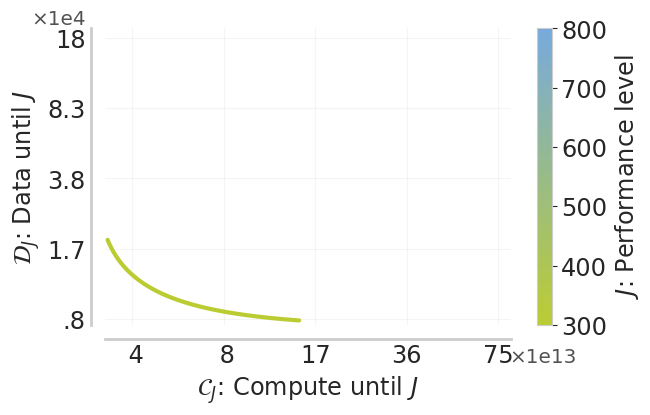

In [25]:
# Step 1 - interpolate the pareto frontier from large to small


fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

i = 0
# Generate smooth curves and plot fits for each threshold
x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
a, b, c = fits[i]
y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
utd = x_smooth
data = y_fitted

# Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
grad_steps = utd * data
batch_sizes = 300 * (utd)**(-0.3)
compute = grad_steps * batch_sizes * 10 * 1.5e5

# Plot the fit
plt.plot(compute, data, '-',
            color=colors[i],
        #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
            linewidth=3)

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

plt.xlim((3.2e13), (83e13))
x = np.logspace(np.log10(4e13), np.log10(83e13 * 0.9), num=5, dtype=int)
xlabels = ["%2.f" % (y/1e13) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

plt.ylim((75000), (2000000))
yticks = np.logspace(np.log10(80000), np.log10(2000000 * 0.9), num=5, dtype=int)
ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: Compute until $J$',
                                       ylabel='$\mathcal{D}_J$: Data until $J$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.045, 1, '×1e4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$J$: Performance level', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')

plt.savefig('gif_frontier_small.pdf', dpi=300, bbox_inches='tight')


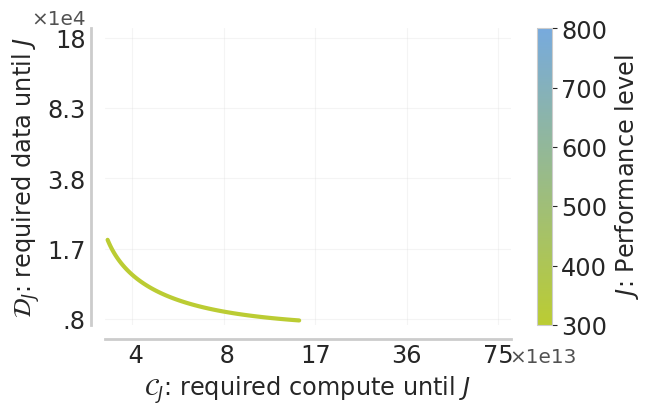

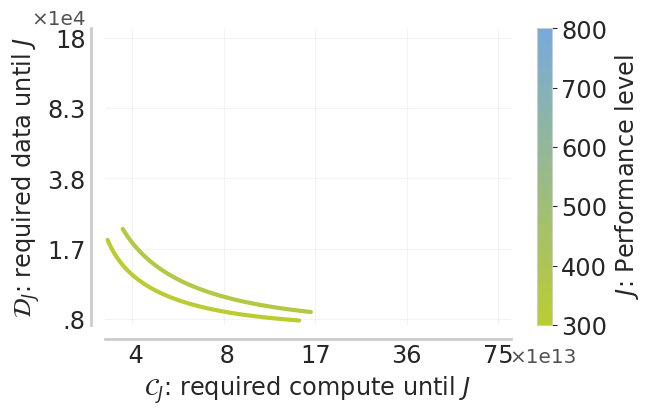

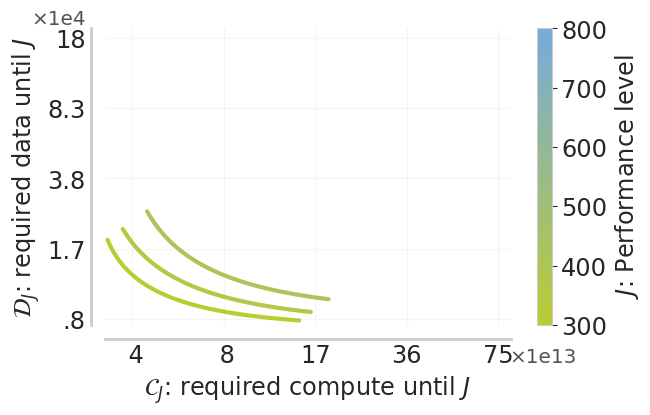

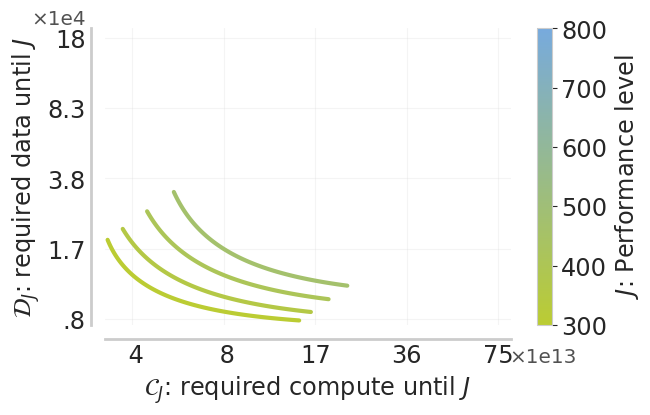

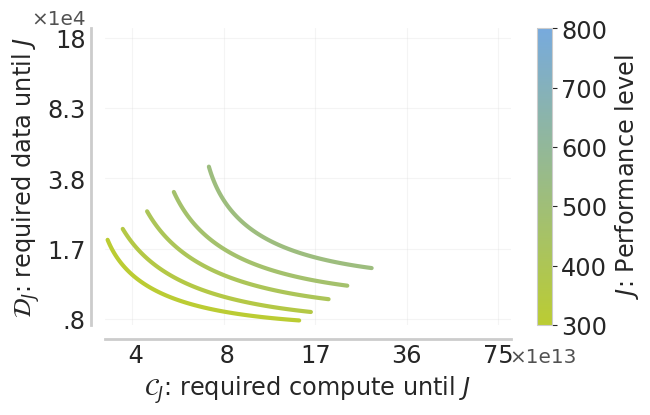

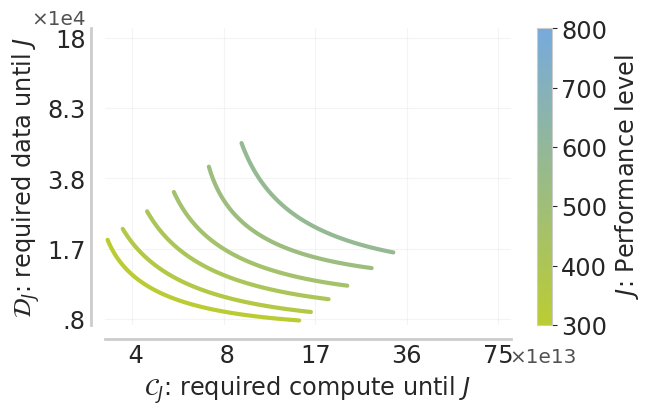

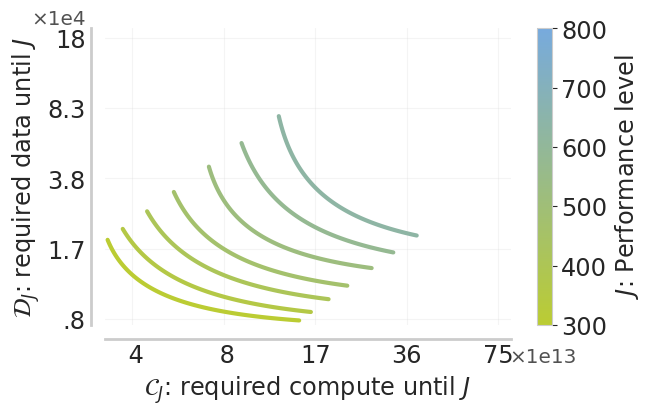

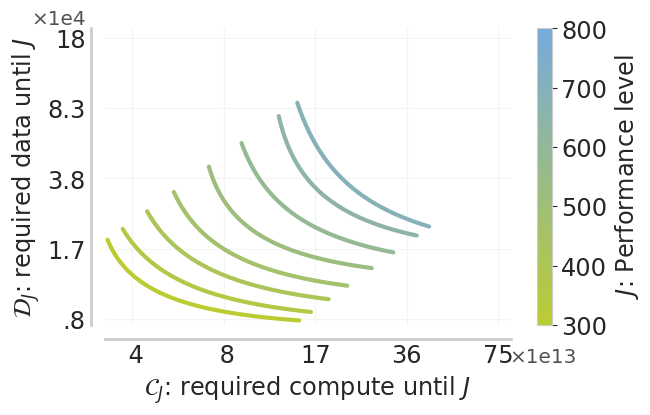

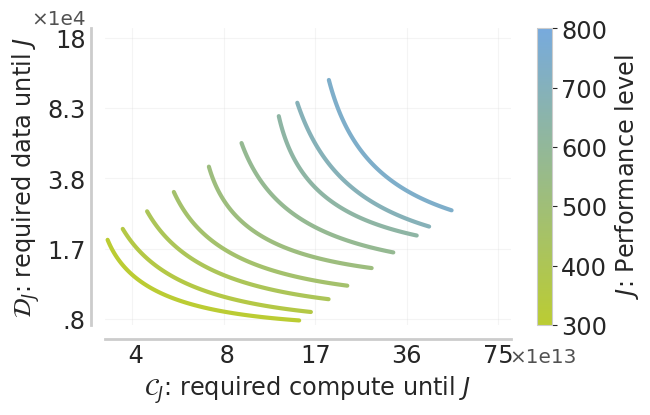

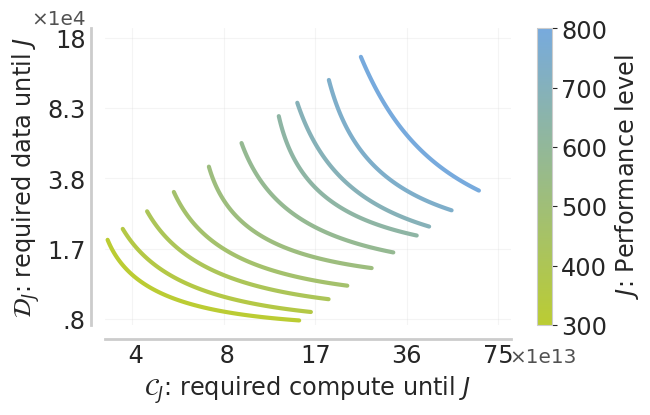

In [26]:
# Plot pareto fits

import matplotlib.animation as animation


for frame in range(n_thresholds):

    fig, axs = plt.subplots(1, 1)
    fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)
    
    # Plot fits up to current frame cumulatively
    for i in range(frame + 1):
        # Generate smooth curves and plot fits
        x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
        a, b, c = fits[i]
        y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
        utd = x_smooth
        data = y_fitted

        # Convert UTD ratio to compute
        grad_steps = utd * data
        batch_sizes = 300 * (utd)**(-0.3)
        compute = grad_steps * batch_sizes * 10 * 1.5e5
        
        # Plot the fit
        axs.plot(compute, data, '-',
                color=colors[i],
                linewidth=3)

    # Set scales and limits
    axs.set_xscale('log')
    axs.set_yscale('log') 
    axs.set_xlim((3.2e13), (83e13))
    axs.set_ylim((75000), (2000000))

    # X ticks
    x = np.logspace(np.log10(4e13), np.log10(83e13 * 0.9), num=5, dtype=int)
    xlabels = ["%2.f" % (y/1e13) for y in x]
    axs.xaxis.set_major_locator(plt.FixedLocator(x))
    axs.xaxis.set_minor_locator(plt.NullLocator())
    axs.set_xticks(x, xlabels, size=14.5)

    # Y ticks
    yticks = np.logspace(np.log10(80000), np.log10(2000000 * 0.9), num=5, dtype=int)
    ylabels = [("%.2g" % (y/100000)).replace('0.', '.') for y in yticks]
    axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
    axs.yaxis.set_minor_locator(plt.NullLocator())
    axs.set_yticks(yticks, ylabels, size=14.5)

    plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: required compute until $J$',
                                        ylabel='$\mathcal{D}_J$: required data until $J$',
                                        labelsize='xx-large', ticklabelsize='xx-large',
                                        grid_alpha=0.2, legend=False)

    plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes,
            horizontalalignment='right', verticalalignment='bottom',
            fontsize='x-large', alpha=0.8)
    plt.text(-0.045, 1, '×1e4', transform=axs.transAxes,
            horizontalalignment='right', verticalalignment='bottom',
            fontsize='x-large', alpha=0.8)

    # Add colorbar for final frame
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('$J$: Performance level', size='xx-large')
    cbar.ax.tick_params(labelsize='xx-large')
    
    plt.savefig(f'gif2/gym_frontier_frame_{frame:03d}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


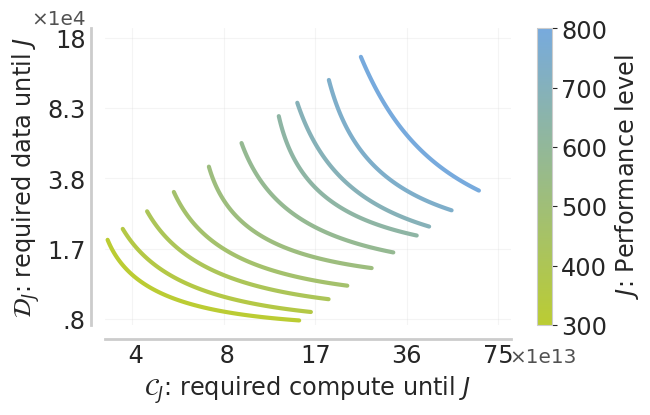

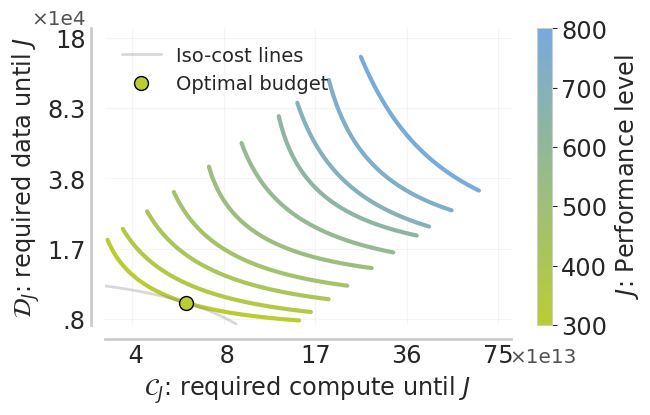

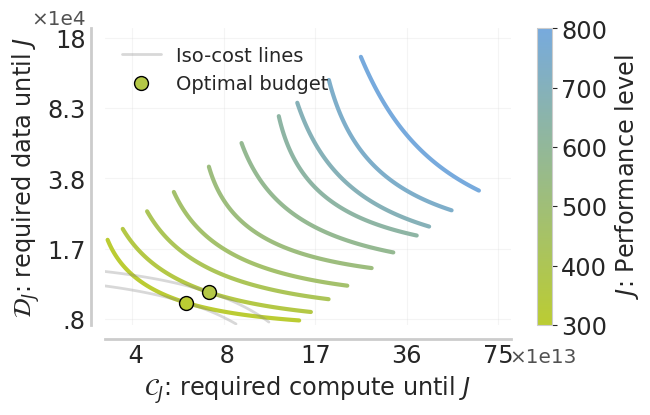

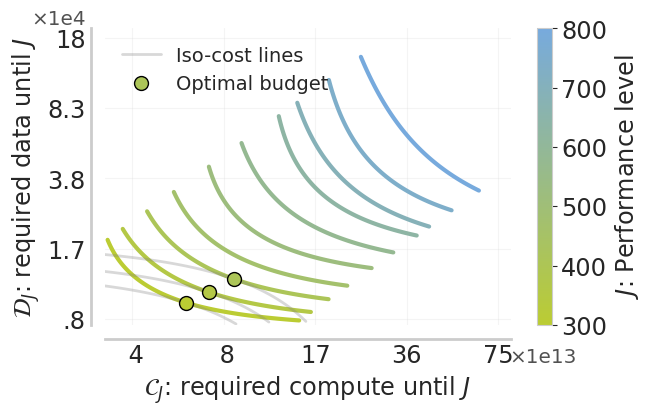

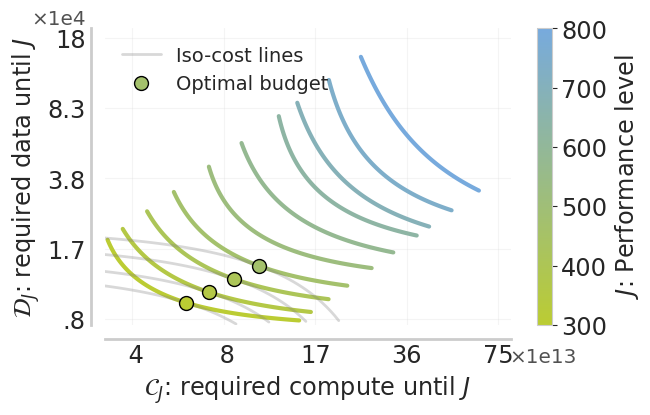

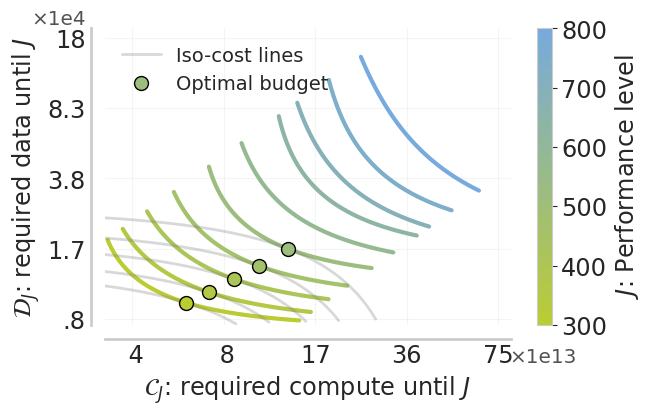

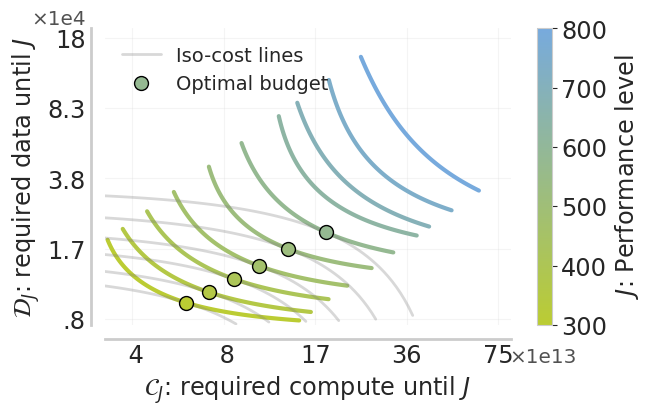

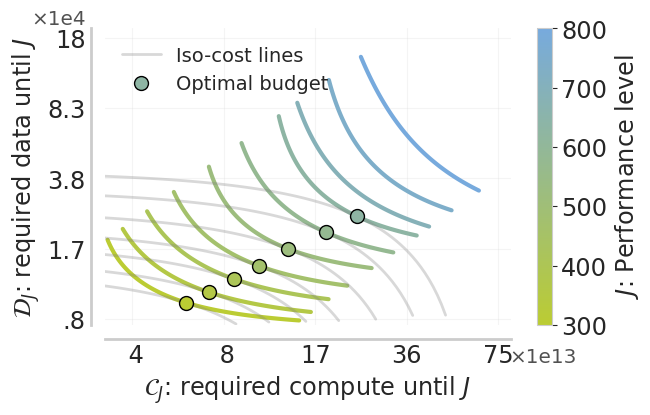

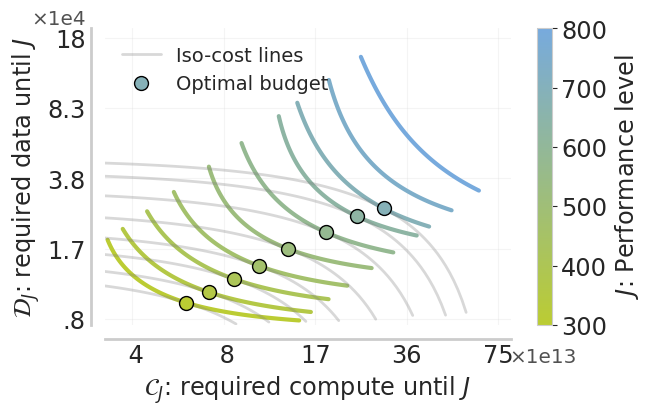

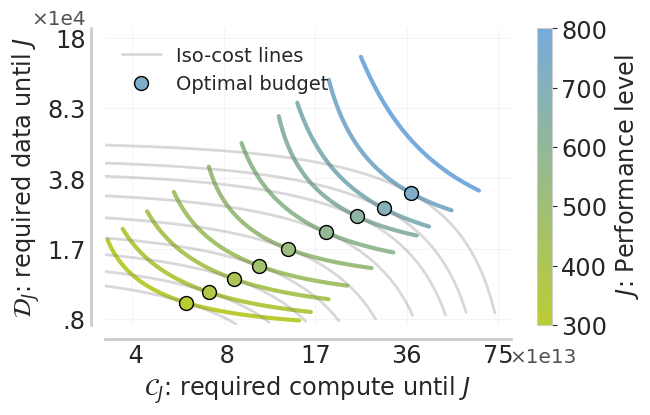

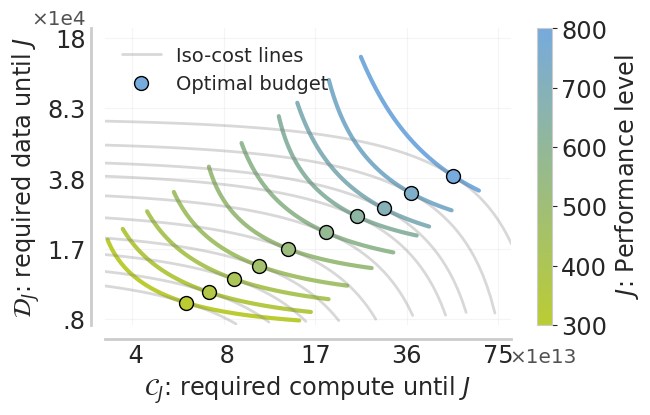

In [27]:
# Plot pareto fits

for frame in range(n_thresholds + 1):  # +1 for final frame with all elements
    fig, axs = plt.subplots(1, 1)
    fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
    n_colors = n_thresholds
    colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

    min_points_compute = []
    min_points_data = []
    min_points_utd = []

    # Plot all fits in every frame
    for i in range(n_thresholds):
        # Generate smooth curves and plot fits for each threshold
        x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
        a, b, c = fits[i]
        y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
        utd = x_smooth
        data = y_fitted

        # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
        grad_steps = utd * data
        batch_sizes = 300 * (utd)**(-0.3)
        compute = grad_steps * batch_sizes * 10 * 1.5e5
        
        # Plot the fit
        plt.plot(compute, data, '-',
                color=colors[i],
                linewidth=3)
        
        # Only show optimal points up to current frame
        if i < frame:
            # Find and mark minimum point
            beta = 1.5e9
            min_idx = np.argmin(compute + beta * data)
            
            # Store min points for fitting line
            min_points_compute.append(compute[min_idx])
            min_points_data.append(data[min_idx])
            min_points_utd.append(utd[min_idx])

            # Add iso-cost line for this point
            compute_min_limit = 3.2e13
            compute_max_limit = 83e13
            data_min_limit = 75000
            data_max_limit = 2000000
            compute_range = np.logspace(np.log10(compute_min_limit), np.log10(compute_max_limit), 100)
            
            budget = compute[min_idx] + beta * data[min_idx]
            data_range = (budget - compute_range) / beta
            
            valid_points = (compute_range >= compute_min_limit) & \
                        (compute_range <= compute_max_limit) & \
                        (data_range >= data_min_limit) & \
                        (data_range <= data_max_limit)
                        
            plt.plot(compute_range[valid_points], data_range[valid_points],
                    '-', color='gray', alpha=0.3, linewidth=2,
                    label='Iso-cost lines'  if i == min(frame-1, len(thresholds)-1) else None,
                    )


            plt.plot(compute[min_idx], data[min_idx], 'o',
                    color=colors[i],
                    markersize=10,
                    label='Optimal budget' if i == min(frame-1, len(thresholds)-1) else None,
                    markeredgecolor='black',
                    )
            
    plt.xscale('log')
    plt.yscale('log')
    axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

    plt.xlim((3.2e13), (83e13))
    x = np.logspace(np.log10(4e13), np.log10(83e13 * 0.9), num=5, dtype=int)
    xlabels = ["%2.f" % (y/1e13) for y in x]
    axs.xaxis.set_major_locator(plt.FixedLocator(x))
    axs.xaxis.set_minor_locator(plt.NullLocator()) 
    axs.set_xticks(x, xlabels, size=14.5)

    plt.ylim((75000), (2000000))
    yticks = np.logspace(np.log10(80000), np.log10(2000000 * 0.9), num=5, dtype=int)
    ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
    axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
    axs.yaxis.set_minor_locator(plt.NullLocator()) 
    axs.set_yticks(yticks, ylabels, size=14.5)

    plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: required compute until $J$',
                                        ylabel='$\mathcal{D}_J$: required data until $J$',
                                        labelsize='xx-large', ticklabelsize='xx-large',
                                        grid_alpha=0.2, legend=False)

    plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
            horizontalalignment='right', verticalalignment='bottom',
            fontsize='x-large', alpha=0.8)
    plt.text(-0.045, 1, '×1e4', transform=axs.transAxes,
            horizontalalignment='right', verticalalignment='bottom', 
            fontsize='x-large', alpha=0.8)

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('$J$: Performance level', size='xx-large')
    cbar.ax.tick_params(labelsize='xx-large')

    plt.savefig(f'gif3/gym_isocost_{frame:03d}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


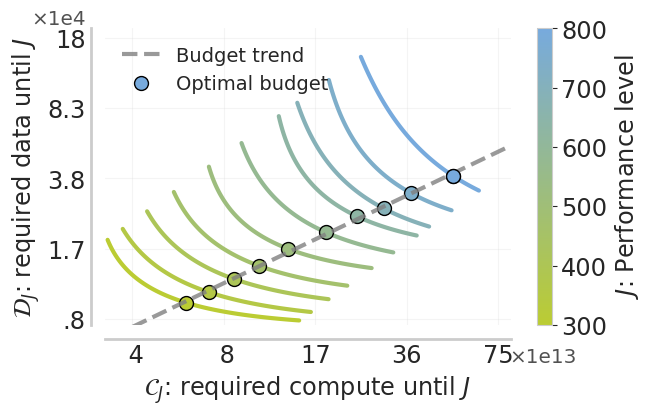

In [28]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]


min_points_compute = []
min_points_data = []
min_points_utd = []

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 300 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 1.5e5
    
    # Plot the fit
    plt.plot(compute, data, '-',
             color=colors[i],
            #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
             linewidth=3)
    
    # Find and mark minimum point
    beta = 1.5e9
    min_idx = np.argmin(compute + beta * data)
    plt.plot(compute[min_idx], data[min_idx], 'o',
                color=colors[i],
                markersize=10,
                # label='Optimal budget' if i == len(thresholds) - 1 else None,
                markeredgecolor='black',
                )
    
    # Store min points for fitting line
    min_points_compute.append(compute[min_idx])
    min_points_data.append(data[min_idx])
    min_points_utd.append(utd[min_idx])
    
    utds = np.array(utds)
    data_points = np.mean(normalized_times_all[..., i], axis=0) * median_median
    compute_points = utds * data_points * 400 * utds**(-0.3) * 10 * 4.92e6
    # plt.scatter(compute_points[:-1], data_points[:-1], marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
    
    
# UTD extrapolation line
min_points_utd = np.array(min_points_utd)
min_points_data = np.array(min_points_data)
min_points_compute = np.array(min_points_compute)
# Fit line in log space
coeffs = np.polyfit(np.log10(min_points_compute), np.log10(min_points_data), 1)
# Generate points for the fitted line
x_range = np.log10(min(min_points_compute)), np.log10(max(min_points_compute))
x_line = np.logspace(x_range[0] - 0.2 * (x_range[1] - x_range[0]), x_range[1] + 0.2 * (x_range[1] - x_range[0]), 100)
y_line = 10**(coeffs[0] * np.log10(x_line) + coeffs[1])
plt.plot(x_line, y_line, '--', color='gray', 
         label='Budget trend',
        linewidth=3, alpha=0.8)


plt.plot(compute[min_idx], data[min_idx], 'o',
            color=colors[i],
            markersize=10,
            label='Optimal budget' if i == len(thresholds) - 1 else None,
            markeredgecolor='black',
            )
    

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

plt.xlim((3.2e13), (83e13))
x = np.logspace(np.log10(4e13), np.log10(83e13 * 0.9), num=5, dtype=int)
xlabels = ["%2.f" % (y/1e13) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

plt.ylim((75000), (2000000))
yticks = np.logspace(np.log10(80000), np.log10(2000000 * 0.9), num=5, dtype=int)
ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: required compute until $J$',
                                       ylabel='$\mathcal{D}_J$: required data until $J$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.045, 1, '×1e4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$J$: Performance level', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')

plt.savefig('gif_budget_trend.png', dpi=300, bbox_inches='tight')



[1.65550656 1.83882971 1.97218922 2.11522052 2.26862504 2.70259145
 3.00186394 3.57609197 3.83544491 4.73191527]


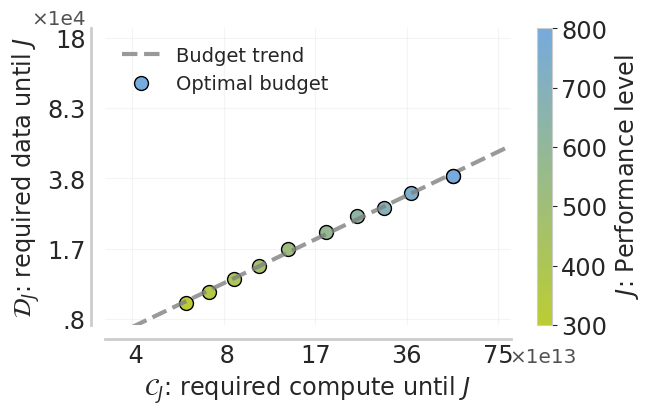

In [30]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]


min_points_compute = []
min_points_data = []
min_points_utd = []

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 300 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 1.5e5
    
    # # Plot the fit
    # plt.plot(compute, data, '-',
    #          color=colors[i],
    #         #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
    #          linewidth=3)
    
    # Find and mark minimum point
    beta = 1.5e9
    min_idx = np.argmin(compute + beta * data)
    plt.plot(compute[min_idx], data[min_idx], 'o',
                color=colors[i],
                markersize=10,
                # label='Optimal budget' if i == len(thresholds) - 1 else None,
                markeredgecolor='black',
                )
    
    # Store min points for fitting line
    min_points_compute.append(compute[min_idx])
    min_points_data.append(data[min_idx])
    min_points_utd.append(utd[min_idx])
    
    utds = np.array(utds)
    data_points = np.mean(normalized_times_all[..., i], axis=0) * median_median
    compute_points = utds * data_points * 400 * utds**(-0.3) * 10 * 4.92e6
    # plt.scatter(compute_points[:-1], data_points[:-1], marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
    
    
# UTD extrapolation line
min_points_utd = np.array(min_points_utd)
print(min_points_utd)
min_points_data = np.array(min_points_data)
min_points_compute = np.array(min_points_compute)
# Fit line in log space
coeffs = np.polyfit(np.log10(min_points_compute), np.log10(min_points_data), 1)
# Generate points for the fitted line
x_range = np.log10(min(min_points_compute)), np.log10(max(min_points_compute))
x_line = np.logspace(x_range[0] - 0.2 * (x_range[1] - x_range[0]), x_range[1] + 0.2 * (x_range[1] - x_range[0]), 100)
y_line = 10**(coeffs[0] * np.log10(x_line) + coeffs[1])
plt.plot(x_line, y_line, '--', color='gray', 
         label='Budget trend',
        linewidth=3, alpha=0.8)


plt.plot(compute[min_idx], data[min_idx], 'o',
            color=colors[i],
            markersize=10,
            label='Optimal budget' if i == len(thresholds) - 1 else None,
            markeredgecolor='black',
            )
    

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='upper left')

plt.xlim((3.2e13), (83e13))
x = np.logspace(np.log10(4e13), np.log10(83e13 * 0.9), num=5, dtype=int)
xlabels = ["%2.f" % (y/1e13) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

plt.ylim((75000), (2000000))
yticks = np.logspace(np.log10(80000), np.log10(2000000 * 0.9), num=5, dtype=int)
ylabels = [("%.2g" % (y/100000)).replace('0.', '.')  for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_J$: required compute until $J$',
                                       ylabel='$\mathcal{D}_J$: required data until $J$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.16, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.045, 1, '×1e4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$J$: Performance level', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')

plt.savefig('gif_budget_trend_only.png', dpi=300, bbox_inches='tight')



10
8


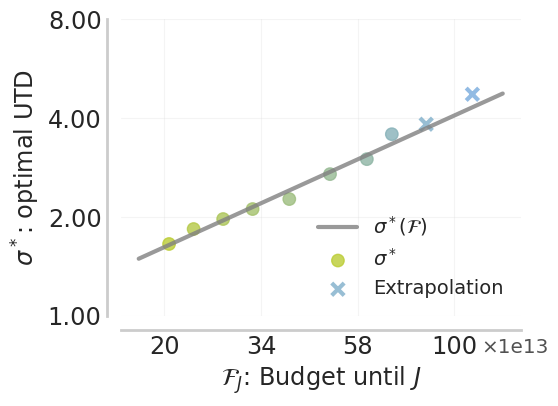

In [21]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 , 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = np.array([cmap(i / (n_colors - 1)) for i in range(n_colors)])

# Fit line in log space

min_points_budget = min_points_compute + beta * min_points_data
fit_points = [0,1,2,3,4,5,6,7]
print(len(min_points_budget))
print(len(min_points_budget[fit_points]))
coeffs = np.polyfit(np.log10(min_points_budget[fit_points]), np.log10(min_points_utd[fit_points]), 1)
# Generate points for the fitted line
budget_range = np.log10(min(min_points_budget)), np.log10(max(min_points_budget))
budget_line = np.logspace(budget_range[0] - 0.1 * (budget_range[1] - budget_range[0]), budget_range[1] + 0.1 * (budget_range[1] - budget_range[0]), 100)
utd_line = 10**(coeffs[0] * np.log10(budget_line) + coeffs[1])
plt.plot(budget_line, utd_line, color='gray', linewidth=3, alpha=0.8, label='$\sigma^*(\mathcal{F})$')
plt.scatter(min_points_budget[fit_points], min_points_utd[fit_points], marker='o', color=colors[fit_points], label='$\sigma^*$', alpha=0.8, s=80)
plt.scatter(min_points_budget[-2:], min_points_utd[-2:], marker='x', color=colors[-2:], label='Extrapolation', alpha=0.8, s=80, linewidth=3)
    

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='lower right')


x = np.logspace(np.log10(20e13), np.log10(100e13), num=4, dtype=int)
xlabels = ["%2.f" % (y/1e13) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

yticks = np.logspace(np.log10(1), np.log10(8), num=4)
ylabels = ["%2.2f" % (y) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{F}_J$: Budget until $J$',
                                       ylabel='$\sigma^*$: optimal UTD',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.07, -0.14, '×1e13', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)

# Save fits
np.save('fits.npy', fits)   
plt.savefig('gym_budget_fit.pdf', dpi=300, bbox_inches='tight')